In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from scipy.signal import stft
from tqdm import tqdm
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


In [ ]:
# 1. STFT 이미지 생성 함수
def create_stft_image(signal_row, save_path):
    signal = np.array(signal_row)

    f, t, Zxx = stft(signal, nperseg=min(32, len(signal)))
    spectrogram = np.abs(Zxx)

    # 정규화 후 이미지 변환
    spectrogram = (spectrogram - np.min(spectrogram)) / (np.max(spectrogram) - np.min(spectrogram) + 1e-8)
    spectrogram = (spectrogram * 255).astype(np.uint8)
    img = Image.fromarray(spectrogram)
    img = img.convert("RGB")
    img = img.resize((224, 224))
    img.save(save_path)


In [ ]:
concat_df = pd.read_csv("/content/concat.csv")

In [ ]:
# 2. 데이터 불러오기
X_data = concat_df.drop('normal', axis=1).values
y_data = concat_df[['normal']].values  # 1: 정상, 0: 불량

# 학습/테스트 분할 (stratify 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, stratify=y_data, random_state=42
)

# 스케일링
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용 (불균형 해소)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# float32 타입 변환 (DNN 입력을 위한)
X_train_balanced = X_train_balanced.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

# y는 0 또는 1 형태 유지 (sigmoid 사용할 거니까)
y_train_balanced = y_train_balanced.astype('int')
y_test = y_test.astype('int')
y_train_balanced = to_categorical(y_train_balanced, 2)
y_test = to_categorical(y_test, 2)


In [ ]:
# 3. STFT 이미지 생성 및 저장
save_dir = 'stft_images_224'
os.makedirs(save_dir, exist_ok=True)

image_paths = []
labels = []

for idx, (signal_row, label_row) in tqdm(enumerate(zip(X_train_balanced, y_train_balanced)), total=len(X_train_balanced)):
    save_path = os.path.join(save_dir, f"{idx}.png")
    create_stft_image(signal_row, save_path)
    image_paths.append(save_path)
    labels.append(np.argmax(label_row))

result_df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})
result_df.to_csv('stft_image_label_mapping_224.csv', index=False)

print("✅ 224x224 STFT 이미지 변환 완료")


100%|██████████| 36232/36232 [04:09<00:00, 145.30it/s]

✅ 224x224 STFT 이미지 변환 완료


In [ ]:
# 4. Keras 데이터셋 준비
image_dir = 'stft_images_224'
csv_path = 'stft_image_label_mapping_224.csv'

# train/val 분리
df = pd.read_csv(csv_path)
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['label'])

train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

# ImageDataGenerator로 데이터 로드
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='',
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory='',
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 32608 validated image filenames belonging to 2 classes.
Found 3624 validated image filenames belonging to 2 classes.


In [ ]:
# 5. ResNet50 모델 불러오기
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

# 6. 모델 컴파일
model.compile(optimizer=Adam(learning_rate =0.001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 76,957,576 (293.57 MB)

 Trainable params: 25,634,818 (97.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 51,269,638 (195.58 MB)

In [ ]:
print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")


Train samples: 32608
Validation samples: 3624


In [ ]:
# 7. 모델 학습
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=5,
    validation_data=val_generator,
    validation_steps=len(val_generator)
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 583s 512ms/step - accuracy: 0.7334 - loss: 0.6008 - val_accuracy: 0.5006 - val_loss: 1.0103
Epoch 2/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 514s 491ms/step - accuracy: 0.8722 - loss: 0.3121 - val_accuracy: 0.8615 - val_loss: 0.3550
Epoch 3/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 500s 490ms/step - accuracy: 0.8935 - loss: 0.2612 - val_accuracy: 0.8565 - val_loss: 0.4221
Epoch 4/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 501s 491ms/step - accuracy: 0.9110 - loss: 0.2207 - val_accuracy: 0.7729 - val_loss: 0.7126
Epoch 5/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 511s 500ms/step - accuracy: 0.9182 - loss: 0.1960 - val_accuracy: 0.8943 - val_loss: 0.2705


In [ ]:
# 8. 모델 저장
model.save('resnet50_stft_finetuned.h5')
print("✅ 모델 저장 완료!")


✅ 모델 저장 완료!


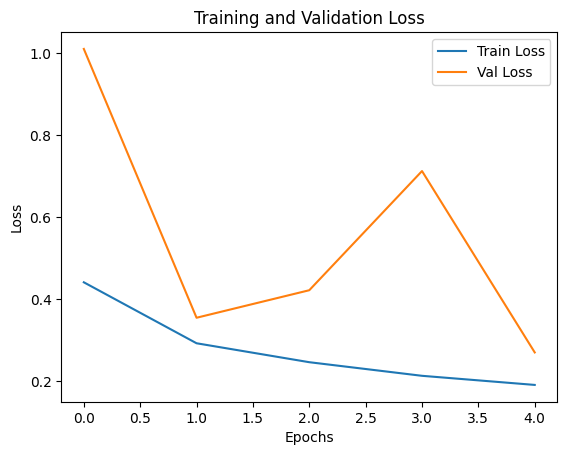

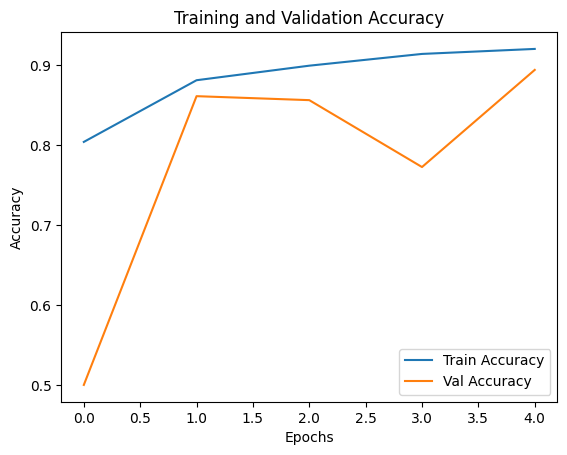

In [ ]:
# 9. 학습 과정 시각화 (Loss, Accuracy)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# (1) X_test_scaled → STFT 변환해서 이미지 저장
save_dir_test = 'stft_test_images_224'
os.makedirs(save_dir_test, exist_ok=True)

test_image_paths = []
test_labels = []

for idx, (signal_row, label_row) in tqdm(enumerate(zip(X_test_scaled, y_test)), total=len(X_test_scaled)):
    save_path = os.path.join(save_dir_test, f"{idx}.png")
    create_stft_image(signal_row, save_path)
    test_image_paths.append(save_path)
    test_labels.append(np.argmax(label_row))  # one-hot이면 이렇게

test_result_df = pd.DataFrame({
    'image_path': test_image_paths,
    'label': test_labels
})
test_result_df.to_csv('stft_test_image_label_mapping_224.csv', index=False)

print("✅ 테스트 데이터 STFT 이미지 변환 완료")


100%|██████████| 6410/6410 [00:44<00:00, 143.95it/s]

✅ 테스트 데이터 STFT 이미지 변환 완료


In [ ]:
# (2) 테스트용 제너레이터 만들기
test_df = pd.read_csv('stft_test_image_label_mapping_224.csv')
test_df['label'] = test_df['label'].astype(str)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='',
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # 테스트니까 섞지 말 것!
)


Found 6410 validated image filenames belonging to 2 classes.


In [ ]:
# (3) 테스트 데이터로 평가
loss_and_metrics_test = model.evaluate(test_generator)
print(f"Test loss: {loss_and_metrics_test[0]:.4f}")
print(f"Test accuracy: {loss_and_metrics_test[1]:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.8501 - loss: 0.3818
Test loss: 0.3645
Test accuracy: 0.8552


In [ ]:
# (4) F1 score 계산
from sklearn.metrics import f1_score

y_pred = model.predict(test_generator)
y_pred_labels = np.argmax(y_pred, axis=1)

y_true_labels = test_generator.classes

f1 = f1_score(y_true_labels, y_pred_labels)
print(f"Test F1 Score: {f1:.4f}")


201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step
Test F1 Score: 0.8870
